In [ ]:
# CELL 1 (do not change)
"""import statements and boiler plate code"""
import tensorflow_datasets as tfds
import tensorflow as tf 
import tensorflow.keras as ks
import tensorflow.keras.backend as K
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import numpy as np

from typing import *
import sys

if sys.version_info >= (3, 8, 0):
    from math import prod
else:
    # math.prod shim for Python 3.7 and older
    def prod(iterable, *, start=1):
        total = start
        for element in iterable:
            total *= element
        return (total)

def pretruberate(latent, model, bit, value):
    if not isinstance(latent, np.ndarray):
        latent = latent.numpy()
    latent[0][bit] = step
    return model.decode(latent)

def pretruberate_range(latent, image, model, bit, vals):
    fig, ax = plt.subplots(1, 11)
    fig.set_size_inches(w = 15, h = 30)
    for i, step in enumerate(vals):
        rec = pretruberate(latent, model, bit, step)
        ax[i].imshow(rec[0, :, :, 0])
        ax[i].axis('off')
    ax[10].imshow(image[0, :, :, 0])
    ax[10].axis('off')
    plt.show()
    pass

def get_sample(val, index, model, batch_size = None):
    sample = val.skip(index).take(1)
    for image, label in sample:
        break
    if batch_size is None:
        latent = model.predict(image).numpy()
    else:
        latent = model.predict(image, batch_size = batch_size).numpy()
    return image, latent


def display(val, model, n = 10, x0 = 0, y0 = 1): 
    image, latent = get_sample(val, 11, model)
    latent = model.predict(image).numpy()
    latent = latent[0, :]
    print(latent.shape)
    norm = tfp.distributions.Normal(0,1)
    vals_x = norm.quantile(np.linspace(0.05, 0.95, n))
    vals_y = norm.quantile(np.linspace(0.05, 0.95, n))

    fig, ax = plt.subplots(n, n)
    fig.set_size_inches(w = 10, h = 10)
    for i, x in enumerate(vals_x):
        for j, y in enumerate(vals_y):
            latent[x0], latent[y0] = x, y
            rec = tf.sigmoid(model.decode(np.array([latent])))
            ax[i, j].imshow(rec[0,:,:,0], cmap='gnuplot2')
            ax[i, j].axis('off')
    plt.subplots_adjust(wspace=0, hspace=0, left=0, right=1, bottom=0, top=1)
    plt.show()
    pass

tfds.core.DatasetInfo(
    name='mnist',
    version=3.0.1,
    description='The MNIST database of handwritten digits.',
    homepage='http://yann.lecun.com/exdb/mnist/',
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=tf.uint8),
        'label': ClassLabel(shape=(), dtype=tf.int64, num_classes=10),
    }),
    total_num_examples=70000,
    splits={
        'test': 10000,
        'train': 60000,
    },
    supervised_keys=('image', 'label'),
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year={2010}
    }""",
    redistribution_info=,
)

random value:  27
shape:  [28 28 1]
random value:  27
shape:  [28 28 1]


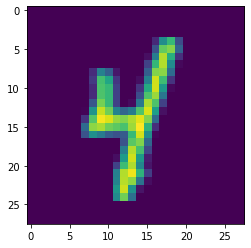

random value:  27
shape:  [28 28 1]


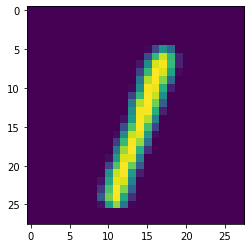

random value:  26
shape:  [28 28 1]


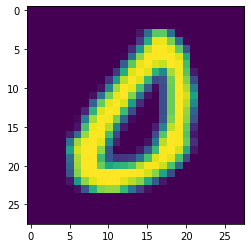

random value:  26
shape:  [28 28 1]


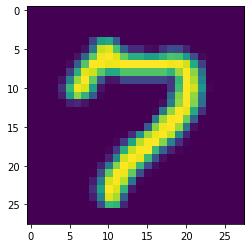

random value:  26
shape:  [28 28 1]


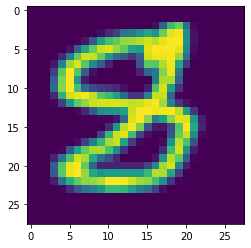

random value:  27
shape:  [28 28 1]


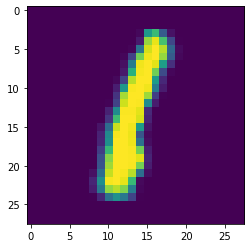

random value:  27
shape:  [28 28 1]


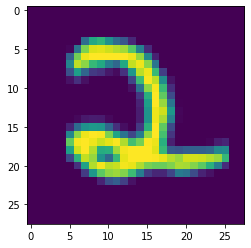

random value:  26
shape:  [28 28 1]


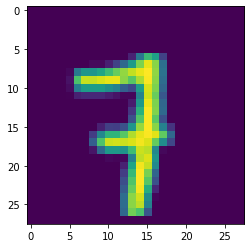

random value:  27
shape:  [28 28 1]


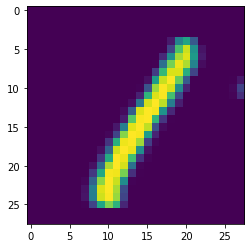

random value:  26
shape:  [28 28 1]


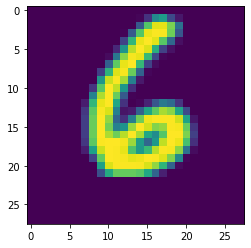

random value:  27
shape:  [28 28 1]


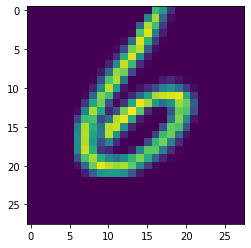

random value:  27
shape:  [28 28 1]


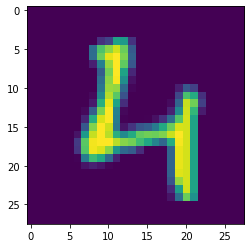

In [ ]:
# CELL 2
def preprocess(image: tf.Tensor, label: tf.Tensor, disp: bool = False):
    # TODO: fill in this function
    image = tf.cast(image,tf.float32)/255.0
    randint = tf.random.uniform(shape=(), minval = 26, maxval = 28, dtype = tf.int64)
    #print(tf.size(image))
    image = tf.image.random_crop(image,size = (randint,randint,1))
    image = tf.image.resize(image,[28,28])
    
    if disp:
        tf.print("random value: ", randint)
        tf.print("shape: ",tf.shape(image))
    return image, image

"""script to load data set and print info"""
(train, test), info = tfds.load("mnist", split = ['train', 'test'], with_info=True, shuffle_files=True, as_supervised = True)
print(info)

""" Test """
train = train.map(lambda x, y: preprocess(x, y, disp = True)).batch(1)
for i, (image, _) in enumerate(train):
    plt.imshow(image[0, ..., 0])
    plt.show()
    if i > 10:
        break

In [ ]:
# CELL 3
""" Custom Building Blocks """
class ResidualBlock(ks.layers.Layer):
    def __init__(self, 
                 filters: int, 
                 dilation_rate: Tuple[int, int] = (1,1), 
                 kernel_initializer: str = 'glorot_uniform', 
                 momentum: float = 0.99, 
                 epsilon: float = 0.001, 
                 downsample: bool = False,
                 use_bias: bool = False, 
                 use_sync: bool = True, 
                 kernel_regularizer = None, 
                 bias_regularizer = None):
        
        # parameters Conv2D
        self._filters = filters
        self._dilation_rate = dilation_rate
        self._kernel_initializer = kernel_initializer
        self._kernel_regularizer = kernel_regularizer
        self._bias_regularizer = bias_regularizer
        self._use_bias = use_bias
        self._use_sync = use_sync

        # parameters Batch Norm
        if K.image_data_format() == "channels_last":
            # channels_last: (batch_size, height, width, channels)
            self._axis = -1
        else:
            # not channels_last: (batch_size, channels, height, width)
            self._axis = 1

        self._momentum = momentum 
        self._epsilon = epsilon 

        # downsample
        self._downsample = downsample

        if downsample:  # convolutional block
            self._strides = (2,2)
        else:   #identity block
            self._strides = (1,1)

        # TODO: set the activation function to the same one that is used in the paper
        self._activation = tf.keras.activations.relu

        super(ResidualBlock, self).__init__()

    def build(self, ishape):
        # TODO: fill in this function
        # 

        if self._downsample:
           self._down_conv2d = tf.keras.layers.Conv2D(filters = self._filters,
                                                kernel_size = 1, 
                                                strides = self._strides, #2 if downsample = True
                                                padding = "same",
                                                kernel_initializer = self._kernel_initializer,
                                                kernel_regularizer = self._kernel_regularizer,
                                                bias_regularizer = self._bias_regularizer,
                                                use_bias = self._use_bias,
                                                dilation_rate = self._dilation_rate)
           self._down_batch_norm = tf.keras.layers.BatchNormalization(axis = self._axis,
                                                                momentum = self._momentum,
                                                                epsilon = self._epsilon)
           
        self._first_conv2d = tf.keras.layers.Conv2D(filters = self._filters,
                                                 kernel_size = (3,3),
                                                 strides = self._strides,  #1 if downsample = False
                                                 padding = "same",  
                                                 kernel_initializer = self._kernel_initializer,
                                                 kernel_regularizer = self._kernel_regularizer,
                                                 bias_regularizer = self._bias_regularizer,
                                                 use_bias = self._use_bias,
                                                 dilation_rate = self._dilation_rate) 

        self._first_batch_norm = tf.keras.layers.BatchNormalization(axis = self._axis,
                                                                momentum = self._momentum,
                                                                epsilon = self._epsilon)
        self._second_conv2d = tf.keras.layers.Conv2D(filters =self._filters,
                                                 kernel_size = (3,3),
                                                 strides = self._strides,  #1 if downsample = False
                                                 padding = "same",  
                                                 kernel_initializer = self._kernel_initializer,
                                                 kernel_regularizer = self._kernel_regularizer,
                                                 bias_regularizer = self._bias_regularizer,
                                                 use_bias = self._use_bias,
                                                 dilation_rate = self._dilation_rate) 
        self._second_batch_norm = tf.keras.layers.BatchNormalization(axis = self._axis,
                                                                momentum = self._momentum,
                                                                epsilon = self._epsilon)
        
                                            
          
        
          


        #raise NotImplementedError
        #super(ResidualBlock, self).build(ishape)

    def call(self, inputs):
        # TODO: fill in this function
        inputs_shortcut = inputs

        output = self._first_conv2d(inputs)
        output = self._first_batch_norm(output)
        output = self._activation(output)

        if self._downsample:
          inputs_shortcut = self._down_conv2d(inputs_shortcut)
          inputs_shortcut = self._down_batch_norm(inputs_shortcut)
        
        output = tf.keras.layers.add([inputs_shortcut,output])

        #raise NotImplementedError
        return self._activation(output)

"""Testing"""
vis = train.take(10)
for image, t in vis:
    x = ResidualBlock(filters = 3)(image)
    y = ResidualBlock(filters = 32, downsample=True)(image)
    print(x.shape, y.shape)

random value:  27
random value:  28
(1, 28, 28, 3) (1, 14, 14, 32)
random value:  28
(1, 28, 28, 3) (1, 14, 14, 32)
random value:  28
(1, 28, 28, 3) (1, 14, 14, 32)
random value:  26
(1, 28, 28, 3) (1, 14, 14, 32)
random value:  27
(1, 28, 28, 3) (1, 14, 14, 32)
random value:  28
(1, 28, 28, 3) (1, 14, 14, 32)
random value:  28
(1, 28, 28, 3) (1, 14, 14, 32)
random value:  28
(1, 28, 28, 3) (1, 14, 14, 32)
random value:  28
(1, 28, 28, 3) (1, 14, 14, 32)
random value:  28
(1, 28, 28, 3) (1, 14, 14, 32)


(10, 10, 2)
Epoch 1/20
1500/1500 [==============================] - 84s 54ms/step - loss: 1302752768.0000 - mean_squared_error: 1901.7946 - loss2: -343.9980 - reg: -153.4516 - val_loss: 3.0139 - val_mean_squared_error: 14.6675
Epoch 2/20
1500/1500 [==============================] - 72s 48ms/step - loss: 298792.3125 - mean_squared_error: 22.5063 - loss2: -216.8967 - reg: -8.0985 - val_loss: 3.4233 - val_mean_squared_error: 19.9673
Epoch 3/20
1500/1500 [==============================] - 71s 47ms/step - loss: 5912.9102 - mean_squared_error: 21.2912 - loss2: -212.6086 - reg: -2.3806 - val_loss: 3.4592 - val_mean_squared_error: 20.9124
Epoch 4/20
1500/1500 [==============================] - 71s 47ms/step - loss: 3607.0776 - mean_squared_error: 22.2559 - loss2: -210.1492 - reg: -1.3245 - val_loss: 3.4438 - val_mean_squared_error: 21.1052
Epoch 5/20
1500/1500 [==============================] - 70s 47ms/step - loss: 966.3542 - mean_squared_error: 23.0677 - loss2: -207.5254 - reg: -0.9356 - val

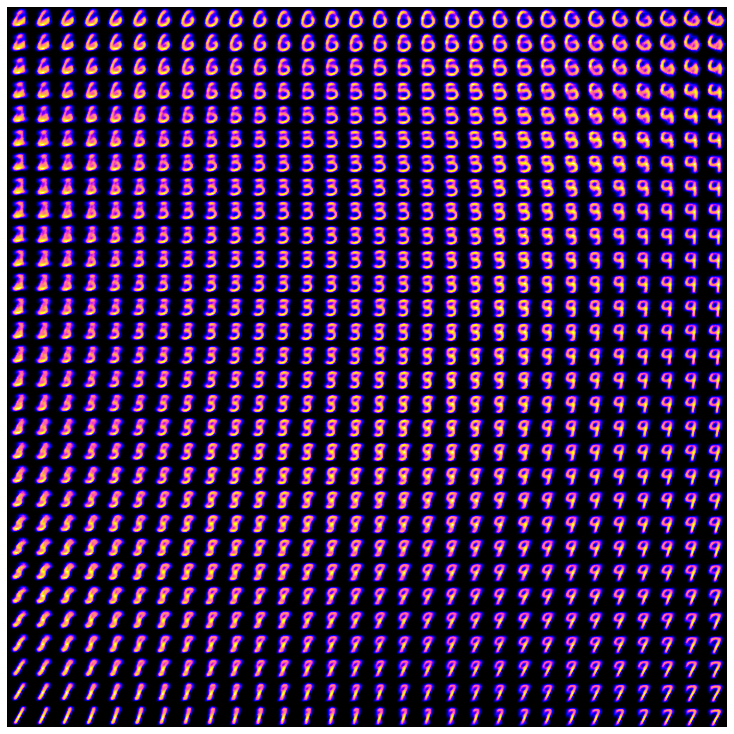

In [ ]:
# CELL 4
'''
testing your pipeline and you custom block together 

mnist input shape  = (28, 28, 1)

DEEP MIND Implementation -> very stable
 -> loss function is more stable 
 -> batch norm causes exploding gradients 
'''

@tf.function
def ae_loss(x, x_reconstruction, loss = ks.losses.mse):
    return -tf.reduce_sum(loss(x, x_reconstruction), axis = [1, 2, 3])

@tf.function
def regularize(z, mu, log_sigma):
    # mu = tf.reduce_sum(mu, axis = [1])
    # sigma = tf.reduce_sum(sigma, axis = [1])
    # term = tf.math.exp(sigma) + (mu ** 2) - 1 - sigma
    log2pi = tf.math.log(2. * np.pi)
    term = -0.5 * (((z - mu) ** 2.) * tf.math.exp(-log_sigma) + log_sigma + log2pi)
    return tf.reduce_sum(term, axis = 1)

@tf.function
def vae_loss(term1, term2):
    return -tf.reduce_mean(term1 + term2)

class VAE(ks.Model):
    def __init__(self, input_shape, latent_size = None, latent_dims = None, batch_size = 40):
        super(VAE, self).__init__()
        self.ishape = input_shape
        self.latent_size = latent_size
        self.batch_size = batch_size
        self.encoder = None
        self.decoder = None

        print(latent_dims)
        self.encoder = self.get_encoder(latent_size)
        self.decoder = self.get_decoder(latent_dims)
        return
    
    def get_encoder(self, latent_size):
        '''
        NOTE
        ----
        the encoder is a simple NN, CNN, RNN, or transformer structure that maps to a latent vector
        the details of the network do not need to be specific, but can be anything
        the attributes of this network:
            - downsample the input vector 
            - map to a vector
        '''
        encoder = ks.Sequential()
        encoder.add(ks.layers.Conv2D(32, kernel_size = (3,3), strides = (1,1), padding = "valid"))
        encoder.add(ks.layers.BatchNormalization())
        encoder.add(ks.layers.ReLU())
        encoder.add(ResidualBlock(64, downsample=True))
        encoder.add(ks.layers.Flatten())
        encoder.add(ks.layers.Dense(512))
        encoder.add(ks.layers.BatchNormalization())
        encoder.add(ks.layers.ReLU())

        # use latent_size + latent_size, so that half the vector is learing the z_mu (mean) other half is learning z_sigma (standard deviation)
        encoder.add(ks.layers.Dense(latent_size + latent_size))
        return encoder
    
    def get_decoder(self, dimension):
        vec_size = prod(dimension)
        decoder = ks.Sequential()
        decoder.add(ks.layers.Dense(vec_size))
        decoder.add(ks.layers.ReLU())
        decoder.add(ks.layers.Reshape(dimension, input_shape = (None, self.latent_size, )))
        decoder.add(ks.layers.Conv2DTranspose(64, kernel_size = (3,3), strides = (1,1), padding = "valid"))
        decoder.add(ks.layers.ReLU())
        decoder.add(ks.layers.Conv2DTranspose(64, kernel_size = (3,3), strides = (2,2), padding = "valid"))
        decoder.add(ks.layers.ReLU())
        decoder.add(ks.layers.Conv2DTranspose(32, kernel_size = (3,3), strides = (1,1), padding = "valid"))
        decoder.add(ks.layers.ReLU())
        decoder.add(ks.layers.Conv2DTranspose(1, kernel_size = (2,2), strides = (1,1), padding = "valid"))
        return decoder

    def reparameterize(self, z_mu, z_sigma):
        sample = tf.random.normal(shape = (self.batch_size, z_mu.shape[-1]), mean = 0, stddev=1)
        z = z_mu + tf.math.exp(z_sigma) * sample
        return z

    def decode(self, inputs):
        self.batch_size = tf.shape(inputs)[0]
        x = self.decoder(inputs)
        return x

    def call(self, inputs):
        self.batch_size = tf.shape(inputs)[0]
        z_full = self.encoder(inputs)

        # num_or_size_splits is a scalar to the value gets split evenly in the same way every time
        z_mu, z_sigma = tf.split(z_full, num_or_size_splits=2, axis = -1)
        z = self.reparameterize(z_mu, z_sigma)
        x = self.decoder(z)
        return x, z, z_mu, z_sigma

    def predict(self, inputs):
        self.batch_size = tf.shape(inputs)[0]
        z_full = self.encoder(inputs)
        z_mu, z_sigma = tf.split(z_full, num_or_size_splits=2, axis = -1)
        z = self.reparameterize(z_mu, z_sigma)
        return z

    def train_step(self, data):
        # use with model.fit
        # unpack the input data
        x, x_reconstruction = data

        with tf.GradientTape() as tape:
            # call self or model to make a prediction
            x_hat, z, z_mu, z_sigma = self(x, training = True)
            p_xz = ae_loss(x, x_hat, loss = tf.nn.sigmoid_cross_entropy_with_logits) # computes sigmoid for you 
            p_z = regularize(z, 0., 0.)
            q_zx = regularize(z, z_mu, z_sigma)
            loss = self.compiled_loss(p_xz, p_z - q_zx , regularization_losses=self.losses)

        trainable_vars = self.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(x, x_hat)
        ret = {m.name: m.result() for m in self.metrics}
        ret.update({"loss2": p_xz, "reg": q_zx})
        return ret
    


EPOCHS = 20
BATCH_SIZE = 80
LATENT_SIZE = 2
loss = vae_loss
optimizer = ks.optimizers.Adam()
printing = False
losses = []

    
(train, test), info = tfds.load("mnist", split = ['train', 'test'], with_info=True, shuffle_files=True, as_supervised = True)
train = train.map(lambda x, y: preprocess(x, y)).batch(40)
test = test.map(lambda x, y: preprocess(x, y)).batch(1)

# if the output looks blurry, increase the epochs or comment out the randome crops. 
# we will still use random crops to test that the data pipeline is functional, so dont delete it
# if you comment it out, in the machine learning question google doc, just leave a 
# note for this part indicating that you choose to comment out the random crops
# commenting it out will not affect your possition on the team

model = VAE(input_shape=(28,28,1), latent_size = LATENT_SIZE, latent_dims = (10,10,2))
model.compile(loss=loss, optimizer=optimizer, metrics = [tf.keras.metrics.MeanSquaredError()])
epoch_data = model.fit(train, epochs=EPOCHS, validation_data=test)

# if you dont want to train again, just this in a new cell
display(test, model, x0 = 0, y0 = 1, n = 30)

In [ ]:
#CELL 5
"""
write the loss function
"""

@tf.function
def ae_loss(x, x_reconstruction, mu, log_sigma, batch_size, latent_size):
    """
    Answers to requested questions for this code block, questions can be found
    on the google doc associated with this assignment. Godspeed. 

    To re-iterate the instruction doc: This step is not required, but it will be
    extra-credit for the competition (see step 7).
    """
    # TODO: fill in this function
    raise NotImplementedError

class VAE(ks.Model):
    def __init__(self, input_shape, latent_size = None, latent_dims = None, batch_size = 40):
        super(VAE, self).__init__()
        self.ishape = input_shape
        self.latent_size = latent_size
        self.batch_size = batch_size
        self.encoder = None
        self.decoder = None

        self.encoder = self.get_encoder(latent_size)
        self.decoder = self.get_decoder(latent_dims)

        print(latent_dims)
        return
    
    def get_encoder(self, latent_size):
        '''
        NOTE
        ----
        the encoder is a simple NN, CNN, RNN, or transformer structure that maps to a latent vector
        the details of the network do not need to be specific, but can be anything
        the attributes of this network:
            - downsample the input vector 
            - map to a vector
        '''
        encoder = ks.Sequential()
        encoder.add(ks.layers.Conv2D(32, kernel_size = (3,3), strides = (1,1), padding = "valid"))
        encoder.add(ks.layers.BatchNormalization())
        encoder.add(ks.layers.ReLU())
        encoder.add(ResidualBlock(64, downsample=True))
        encoder.add(ks.layers.Flatten())
        encoder.add(ks.layers.Dense(512))
        encoder.add(ks.layers.BatchNormalization())
        encoder.add(ks.layers.ReLU())

        # use latent_size + latent_size, so that half the vector is learing the z_mu (mean) other half is learning z_sigma (standard deviation)
        encoder.add(ks.layers.Dense(latent_size + latent_size))
        return encoder
    
    def get_decoder(self, dimension):
        vec_size = prod(dimension)
        decoder = ks.Sequential()
        decoder.add(ks.layers.Dense(vec_size))
        decoder.add(ks.layers.ReLU())
        decoder.add(ks.layers.Reshape(dimension, input_shape = (None, self.latent_size, )))
        decoder.add(ks.layers.Conv2DTranspose(64, kernel_size = (3,3), strides = (1,1), padding = "valid"))
        decoder.add(ks.layers.ReLU())
        decoder.add(ks.layers.Conv2DTranspose(64, kernel_size = (3,3), strides = (2,2), padding = "valid"))
        decoder.add(ks.layers.ReLU())
        decoder.add(ks.layers.Conv2DTranspose(32, kernel_size = (3,3), strides = (1,1), padding = "valid"))
        decoder.add(ks.layers.ReLU())
        decoder.add(ks.layers.Conv2DTranspose(1, kernel_size = (2,2), strides = (1,1), padding = "valid", activation = 'sigmoid'))
        return decoder

    def reparameterize(self, z_mu, z_sigma):
        sample = tf.random.normal(shape = (self.batch_size, z_mu.shape[-1]))
        z = z_mu + tf.math.exp(z_sigma) * sample
        return z

    def decode(self, inputs):
        x = self.decoder(inputs)
        return x

    def call(self, inputs):
        self.batch_size = tf.shape(inputs)[0]
        z_full = self.encoder(inputs)
        # num_or_size_splits is a scalar to the value gets split evenly in the same way every time
        z_mu, z_sigma = tf.split(z_full, num_or_size_splits=2, axis = -1)
        z = self.reparameterize(z_mu, z_sigma)
        x = self.decoder(z)
        return x, z, z_mu, z_sigma

    def predict(self, inputs):
        self.batch_size = tf.shape(inputs)[0]
        tf.print(self.batch_size)
        z_full = self.encoder(inputs)
        z_mu, z_sigma = tf.split(z_full, num_or_size_splits=2, axis = -1)
        z = self.reparameterize(z_mu, z_sigma)
        return z

    def train_step(self, data):
        # use with model.fit
        # unpack the input data
        x, x_reconstruction = data

        with tf.GradientTape() as tape:
            # call self or model to make a prediction
            x_hat, z, z_mu, z_sigma = self(x, training = True)
            loss, kl = ae_loss(x, x_hat, z_mu, z_sigma, tf.shape(x)[0], self.latent_size)

        trainable_vars = self.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.compiled_metrics.update_state(x, x_hat)
        ret = {m.name: m.result() for m in self.metrics}
        ret.update({"loss":loss, "regular": kl})
        return ret
    
(train, test), info = tfds.load("mnist", split = ['train', 'test'], with_info=True, shuffle_files=True, as_supervised = True)
train = train.map(preprocess).batch(40)
test = test.map(preprocess).batch(1)

# if the output looks blurry, increase the epochs or comment out the random crops. 
# we will still use random crops to test that the data pipeline is functional, so dont delete it
# if you comment it out, in the machine learning question google doc, just leave a 
# note for this part indicating that you choose to comment out the random crops
# commenting it out will not affect your possition on the team

LATENT_SIZE = 2
optimizer = 'rmsprop'
model = VAE(input_shape=(28,28,1), latent_size = LATENT_SIZE, latent_dims = (10, 10, 2))
model.compile(loss=None, optimizer=optimizer, metrics = [tf.keras.metrics.MeanSquaredError(), tf.keras.metrics.BinaryCrossentropy()])
epoch_data = model.fit(train, epochs=20, validation_data=test)

# if you dont want to train again, just this in a new cell
display(test, model, x0 = 0, y0 = 1, n = 30)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

0 examples [00:00, ? examples/s]

Shuffling and writing examples to /root/tensorflow_datasets/rock_paper_scissors/3.0.0.incompleteO9564J/rock_paper_scissors-train.tfrecord


  0%|          | 0/2520 [00:00<?, ? examples/s]

0 examples [00:00, ? examples/s]

Shuffling and writing examples to /root/tensorflow_datasets/rock_paper_scissors/3.0.0.incompleteO9564J/rock_paper_scissors-test.tfrecord


  0%|          | 0/372 [00:00<?, ? examples/s]

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    version=3.0.0,
    description='Images of hands playing rock, paper, scissor game.',
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=tf.uint8),
        'label': ClassLabel(shape=(), dtype=tf.int64, num_classes=3),
    }),
    total_num_examples=2892,
    splits={
        'test': 372,
        'train': 2520,
    },
    supervised_keys=('image', 'label'),
    citation="""@ONLINE {rps,
    author = "Laurence Moroney",
    title = "Rock, Paper, Scissors Dataset",
    month = "feb",
    year = "2019",
    url = "http://laurencemoroney.com/rock-paper-scissors-dataset"
    }""",
    redistribution_info=,
)

Tensor("Shape_3:0", shape=(3,), dtype=int32)
random value:  271
shape:  [300 300 3]
ra

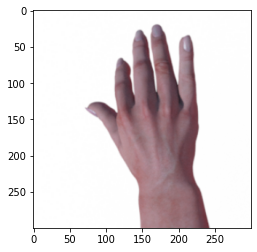

tf.Tensor([[0. 1. 0.]], shape=(1, 3), dtype=float32)
random value:  255
shape:  [300 300 3]
random value:  255


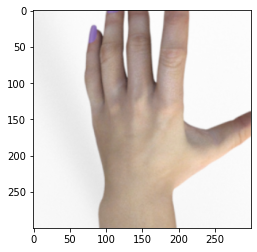

tf.Tensor([[0. 1. 0.]], shape=(1, 3), dtype=float32)
random value:  246
shape:  [300 300 3]
random value:  246


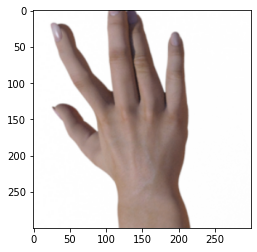

tf.Tensor([[0. 1. 0.]], shape=(1, 3), dtype=float32)
random value:  256
shape:  [300 300 3]
random value:  256


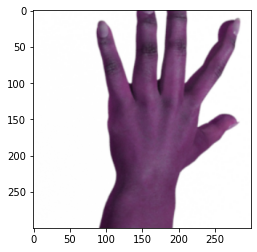

tf.Tensor([[0. 1. 0.]], shape=(1, 3), dtype=float32)
random value:  277
shape:  [300 300 3]
random value:  277


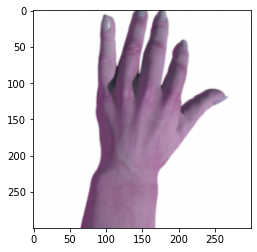

tf.Tensor([[0. 1. 0.]], shape=(1, 3), dtype=float32)
random value:  244
shape:  [300 300 3]
random value:  244


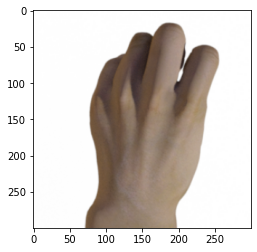

tf.Tensor([[1. 0. 0.]], shape=(1, 3), dtype=float32)
random value:  265
shape:  [300 300 3]
random value:  265


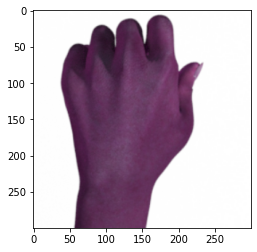

tf.Tensor([[1. 0. 0.]], shape=(1, 3), dtype=float32)
random value:  259
shape:  [300 300 3]
random value:  259


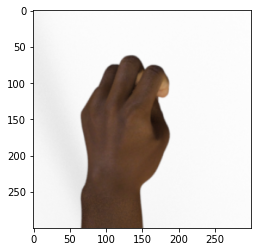

tf.Tensor([[1. 0. 0.]], shape=(1, 3), dtype=float32)
random value:  248
shape:  [300 300 3]
random value:  248


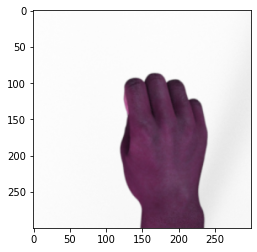

tf.Tensor([[1. 0. 0.]], shape=(1, 3), dtype=float32)
random value:  246
shape:  [300 300 3]
random value:  246


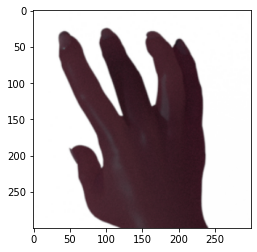

tf.Tensor([[0. 1. 0.]], shape=(1, 3), dtype=float32)
random value:  237
shape:  [300 300 3]
random value:  237


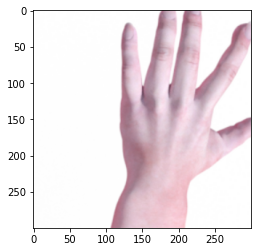

tf.Tensor([[0. 1. 0.]], shape=(1, 3), dtype=float32)
random value:  243
shape:  [300 300 3]
random value:  243


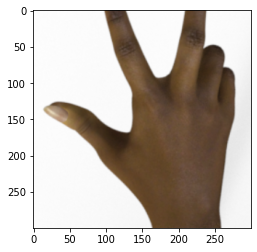

tf.Tensor([[0. 0. 1.]], shape=(1, 3), dtype=float32)


In [ ]:
# CELL 6
# More data pipe lines YAY!!!


'''
copy the pipeline above 

to the pipeline:
    - add a random flip
    - random hue, max alpha = 0.3
    - random brightness, max alpha = 0.3
    - random_contrast, min = 0.9, max = 1.1
'''
def preprocess(image: tf.Tensor, label: tf.Tensor, depth = 3, disp: bool = False):
    shape = tf.shape(image)
    image = tf.cast(image, dtype = tf.float32)
    image = image/255
    
    crop_1 = tf.cast(tf.shape(image)[0] * 22/28, dtype = tf.int32)
    crop_2 = tf.cast(tf.shape(image)[1] * 26/28, dtype = tf.int32)

    randint = tf.random.uniform(shape=(), minval = crop_1, maxval = crop_2 + 1, dtype = tf.int32)
    #print(tf.size(image))
    image = tf.image.random_crop(image, (randint,randint,3))
    print(tf.shape(image))
    image = tf.image.resize(image,[300,300])
    
    if disp:
        tf.print("random value: ", randint)

    """
    copy code from previous pipeline but use crop_1 and crop_2 as the range within which to generate a random number
    """

    # new additions
    if (tf.shape(image)[-1] == 3):
        """
        add:
            - random flip
            - random hue, max alpha = 0.3
            - random brightness, max alpha = 0.1
            - random_contrast, min = 0.9, max = 1.1
        """
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_hue(image = image, max_delta = 0.3)
        tf.image.random_brightness(image = image, max_delta = 0.1)
        tf.image.random_contrast(image,0.9,1.1)

    image = tf.image.resize(image, (shape[0], shape[1]))
    label = tf.one_hot(label, depth)
    if disp:
        tf.print("shape: ", tf.shape(image))
        tf.print("random value: ", randint)
    return image, label

"""script to load data set and print info"""
(train, test), info = tfds.load("rock_paper_scissors", split = ['train', 'test'], with_info=True, shuffle_files=True, as_supervised = True)
print(info)

""" Test """
train = train.map(lambda x, y: preprocess(x, y, disp = True)).batch(1)
for i, (image, label) in enumerate(train):
    if (tf.shape(image)[-1] != 3):
        plt.imshow(image[0, ..., 0])
    else:
        plt.imshow(image[0, ...])
    plt.show()
    print(label)
    if i > 10:
        break

In [ ]:
# CELL 7
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (2,2), activation='relu'),
    tf.keras.layers.MaxPooling2D(3,3),
    #tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Conv2D(32, (2,2), activation='relu'),
    tf.keras.layers.MaxPooling2D(3,3),
    #tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Conv2D(63, (2,2), activation='relu'),
    #tf.keras.layers.MaxPooling2D(3,3),
    #tf.keras.layers.Conv2D(256, (2,2), activation='relu'),
    tf.keras.layers.GlobalMaxPooling2D(),
    #tf.keras.layers.MaxPooling2D(3,3),
    #tf.keras.layers.Flatten(),
    #tf.keras.layers.Dropout(0.6),
    #tf.keras.layers.Dense(512, activation='relu')



])

model.add(ks.layers.Dense(3, activation='softmax'))

                           
"""

BUILD A Conv NN: 

ADD LAYERS TO BUILD A FULL CNN
    - add layers to the sequential model using model.add(<the layer you choose>)
JUST MAKE SURE YOU USE SOFTMAX AS THE LAST LAYER, the soft max layer is provided

competition:
    - the student with the lowest number of parameters and accuracy >= 90% on the validation set will win $15
    - if multiple people have the same number of parameters, the money will be split between the winners, or it will go to the student with higher accuracy.

"""


model.build(input_shape=(None, 300, 300, 3))
model.summary()

"""script to load data set and print info"""
(train, test), info = tfds.load("rock_paper_scissors", split = ['train', 'test'], with_info=True, shuffle_files=True, as_supervised = True)
train = train.map(lambda x, y: preprocess(x, y, disp = False)).batch(40)
test = test.map(lambda x, y: preprocess(x, y, disp = False)).batch(40)

EPOCHS = 75
optimizer = tf.optimizers.Adam() 
# In a nutshell, Adam optimizer is a combination of
# 'gradient descent with momentum' algorithm and the 'RMSP' algorithm.
# Momentum accelerates the gradient descent and RSMP tries to improve AdaGrad.
loss_fn = tf.keras.losses.CategoricalCrossentropy() 
# In this practice, it is reasonable to use catergoricalcrossentropy loss function
# because this is multi-class classification.
metrics_fn = ks.metrics.CategoricalAccuracy()

"""script that will be used to test you model"""
model.compile(optimizer=optimizer, loss = loss_fn, metrics = metrics_fn)
model.fit(train, validation_data = test, epochs=EPOCHS)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 299, 299, 16)      208       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 99, 99, 16)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 98, 98, 32)        2080      
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 31, 31, 63)        8127      
                                                                 
 global_max_pooling2d_1 (Glo  (None, 63)              

KeyboardInterrupt: ignored

In [ ]:
from keras.models import load_model
model.save("rock_papar_scissors.h5")

In [ ]:
from keras.models import load_model
model = load_model('rock_papar_scissors.h5')

OSError: ignored

In [ ]:
# CELL 8
#del model
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (2,2), activation='relu'),
    tf.keras.layers.MaxPooling2D(3,3),
    #tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Conv2D(64, (2,2), activation='relu'),
    tf.keras.layers.MaxPooling2D(3,3),
    #tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Conv2D(128, (2,2), activation='relu'),
    tf.keras.layers.MaxPooling2D(3,3),
    tf.keras.layers.Conv2D(256, (2,2), activation='relu'),
    tf.keras.layers.GlobalMaxPooling2D(),
    #tf.keras.layers.MaxPooling2D(3,3),
    #tf.keras.layers.Flatten(),
    #tf.keras.layers.Dropout(0.6),
    #tf.keras.layers.Dense(512, activation='relu')
])

model.add(ks.layers.Dense(3, activation='softmax'))


(train, test), info = tfds.load("rock_paper_scissors", split = ['train', 'test'], with_info=True, shuffle_files=True, as_supervised = True)
train = train.map(lambda x, y: preprocess(x, y, disp = False)).batch(40)
test = test.map(lambda x, y: preprocess(x, y, disp = False)).batch(40)

#EPOCHS = 5
EPOCHS = 25
optimizer = ks.optimizers.Adam() # default learning rate = 0.001
loss_fn = ks.losses.CategoricalCrossentropy()
#metrics_fn = ks.metrics.CategoricalAccuracy()

train_loss = tf.keras.metrics.Mean()
accuracy = tf.keras.metrics.CategoricalAccuracy()

val_loss = tf.keras.metrics.Mean()
val_accuracy = tf.keras.metrics.CategoricalAccuracy()


# building a custom training loop

for epoch in range(EPOCHS):
    print(f"epoch: {epoch}")
    """
    initialize something to hold all the values of loss and accuracy for validation and training

    """
    for (image,label) in train:
        """
        construct the training loop that would have been appied by calling model.fit
        """
        with tf.GradientTape() as tape:
          #prediction
          prediction = model(image)
          #calculate loss
          loss_value = loss_fn(label,prediction)

    # calculate gradients
        grads = tape.gradient(loss_value,model.trainable_weights)

    #backpropagation
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

    #update loss and accuracy
        train_loss(loss_value)
        accuracy(label,prediction)

    #print(f"avg loss :: {tf.math.reduce_mean(loss)}, avg accuracy :: {tf.math.reduce_mean(accuracy)}", end = "\n")
    print(f"avg loss :: {train_loss.result()}, avg accuracy :: {accuracy.result()}", end = "\n")


    for (image,label) in test: 
        """
        construct the validation loop that would be used to test if the accuracy is similar on the validation set
        """
        logits = model(image)
        loss_value = loss_fn(label,logits)

        val_accuracy(label,logits)
        val_loss(loss_value)

    #print(f"avg val loss :: {tf.math.reduce_mean(val_loss)}, avg val accuracy :: {tf.math.reduce_mean(val_accuracy)}", end = "\n")
    print(f"avg val loss :: {val_loss.result()}, avg val accuracy :: {val_accuracy.result()}", end = "\n")
    
    train_loss.reset_states()
    accuracy.reset_states()
    val_loss.reset_states()
    val_accuracy.reset_states()



Tensor("Shape_3:0", shape=(3,), dtype=int32)
Tensor("Shape_3:0", shape=(3,), dtype=int32)
epoch: 0
avg loss :: 0.9894587397575378, avg accuracy :: 0.5003968477249146
avg val loss :: 0.6499075889587402, avg val accuracy :: 0.8333333134651184
epoch: 1
avg loss :: 0.3609620928764343, avg accuracy :: 0.8722222447395325
avg val loss :: 0.3475169539451599, avg val accuracy :: 0.8763440847396851
epoch: 2
avg loss :: 0.1924743354320526, avg accuracy :: 0.9297618865966797
avg val loss :: 0.11693654209375381, avg val accuracy :: 0.9838709831237793
epoch: 3
avg loss :: 0.0855363979935646, avg accuracy :: 0.9773809313774109
avg val loss :: 0.08260220289230347, avg val accuracy :: 0.9731183052062988
epoch: 4
avg loss :: 0.06708084791898727, avg accuracy :: 0.9785714149475098
avg val loss :: 0.08371565490961075, avg val accuracy :: 0.9704301357269287
epoch: 5
avg loss :: 0.036120060831308365, avg accuracy :: 0.9884920716285706
avg val loss :: 0.039044853299856186, avg val accuracy :: 0.9919354915618

In [ ]:
model.save("seungkeun.h5")

Tensor("Shape_3:0", shape=(3,), dtype=int32)


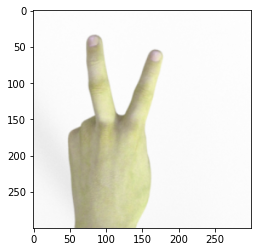

scissors scissors


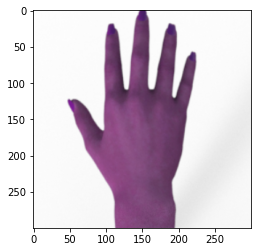

paper paper


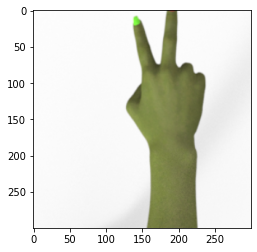

scissors scissors


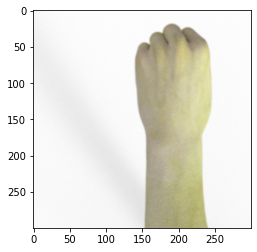

scissors rock


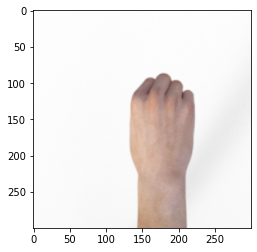

scissors rock


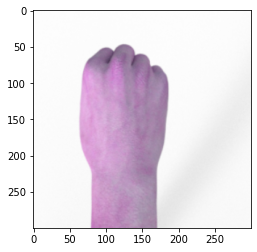

scissors rock


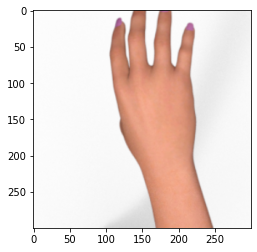

scissors paper


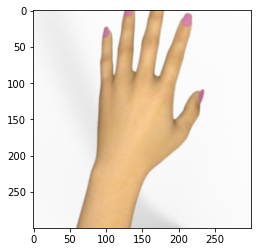

scissors paper


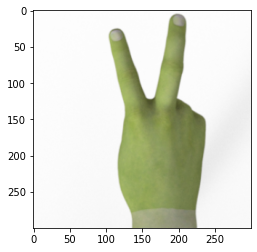

scissors scissors


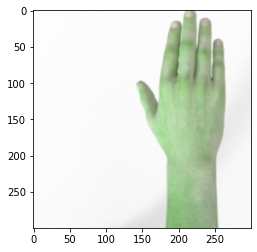

scissors paper


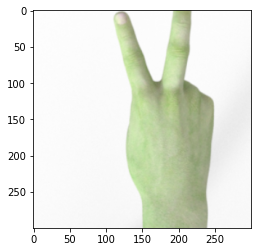

scissors scissors


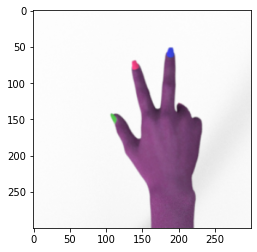

scissors scissors


In [ ]:
# CELL 9
"""visualize/ test the trained model"""
(train, test), info = tfds.load("rock_paper_scissors", split = ['train', 'test'], with_info=True, shuffle_files=True, as_supervised = True)
test = test.map(lambda x, y: preprocess(x, y, disp = False)).batch(1)

class_dict = {0:"rock", 1:"paper", 2:"scissors"}
for i, (image, label) in enumerate(test):
    classif = model(image)
    if (tf.shape(image)[-1] != 3):
        plt.imshow(image[0, ..., 0])
    else:
        plt.imshow(image[0, ...])
    plt.show()
    print(class_dict[int(tf.math.argmax(classif, axis = -1)[0])], class_dict[int(tf.math.argmax(label, axis = -1)[0])])

    if i > 10:
        break

In [ ]:
# CELL 10
""" Read the TFMG Tech Report (https://arxiv.org/abs/2107.00821) and answer the following questions)

1. What is the purpose of the Tensorflow Model Garden?
A:The purpose of the TFMG is to define good examplary of machine learning models by 
reproducing state-of-the-art ML models such as YOLOx and Mesh CNN

2. How does this team's goals differ from those of NeurIPS?
A:NeurIPS added a mandatory reproducibility checklist  but implicity of expert knowledge makes engineers hard to use in practice.
Therefore, the goal of TFMG team is to not only include explicit knowledge but also illustration of engineering processes 
so that engineers will be able to re-implement it a lot more easier.

3. Explain the difference between a custom layer and a custom block.
A: While Tensorflow has predefined layers, custom layers are typically required to perform specific tasks in machine learning models.
a custom block is a component consisting of multiple custom layers. 

4. Explain the importance of training and evaluation checks.
A: Training and Evaluation consists of five parts in this paper; Dataset used, pre-processing functions, output processing functions,
testing and target metrics, training steps. It provides us general checklists and guidelines in order to understand architecture and context
of orginal implementation, especially in training and evaluation part of the model.

5. Which folder would a custom layer belong in according to the Tensorflow Model Garden organizational structure?
A: modeling

6. Why is metric evaluation alone not sufficient to confirm that a model has been successfully reimplemented?
A: Metric evaluation gives us rough estimation of how similar re-implementation is compared to original implemtation.
However, it it does not necessarily mean re-implemented model would generate identical results.
Therefore, in addition to metric evaluationm, we should also use Unit Evaluation, where model is evaluated on a small set of inputs

7. What TensorFlow function should be used when computing values whose gradients can be safely ignored?
A: Gradient Tape

8. Describe the purpose of the datapipeline and its 3 components.
A: The datapipeline is where the data is processed into a format thast will be compatible with
the data handling structure. It consists of extract,transform,load, according to the paper.
"""